# 03-thinking.ipynb
langgraph 로 agent 를 만들 때, 어떻게 생각하고 기획하는지. [참고 문서](https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph#draft-reply)

1. Node 로 단계 쪼개기 + Edge로 연결하기
1. 각 Node의 상세 작성
1. 공유하는 State 를 구성


## 고객 지원 이메일링 agent 기획 튜토리얼

Agent 요구사항:
- 수신 고객 이메일을 읽음
- 급한 정도와 주제로 분류
- 답변에 필요한 관련있는 문서를 검색
- 적절한 대응 초안 작성
- 복잡한 문제는 담당자에게 전달(Human In the Loop)
- 필요시 후속 조치 예약

예시 사용자 시나리오:
1. 단순 제품 질문: "전원 껐다키는 방법 뭐에요?"
2. 버그 리포트: "pdf 추출했더니 꺼져요"
3. 긴급 결제 이슈: "구독료 두번 나감!"
4. 기능 추가 요청: "모바일에서 다크모드 만들어 주세요"
5. 복잡한 기술적 문제: "API연동이 가끔 504 오류 뜨면서 실패함"

## 구현에 필요한 5 단계
1. 워크플로우를 개별 단계로 나눔
2. 각 단계에서 어떤 일을 처리할지 구체화
3. `State` 기획/디자인
4. 필요한 Node/Tool/Router 개발
5. 전체 조립

### 1. 워크플로우를 개별 단계로 나눔
- 그래프 디자인
```mermaid
flowchart TD

    START([START])
    READ[이메일 분석]
    CLASSIFY[의도 분류]

    DOC[문서 검색]
    BUG[버그 추적]
    HR[사람 리뷰]

    DRAFT[답장 초안]

    HR[사람 리뷰]
    SEND[답장 보내기]

    END([END])

    START --> READ
    READ --> CLASSIFY

    CLASSIFY -.-> |내부문서탐색| DOC
    CLASSIFY -.-> |버그리포트| BUG
    CLASSIFY -.-> |복잡한 문제| HR

    DOC --> DRAFT
    BUG --> DRAFT
    HR --> DRAFT

    DRAFT -.-> |긴급 높음| HR
    DRAFT -.-> |기타| SEND

    HR --> END
    SEND --> END
```


### 2. 각 단계에서 어떤 일을 처리할지 구체화
> 단일 노드(함수) | 단일 권한 | 단일 책임

#### LLM 단계
- 의도 분류
    - Input (state): email 내용, 발신자 정보
    - Prompt: 카테고리 분류, 급한 단계, 응답 포맷
    - Output: 구조화된 분류 -> 다음 스텝 결정에 활용
- 초안 작성
    - Input: 분류 결과, 검색 결과, 고객 기록
    - Prompt: 어투 안내, 회사 정책, 답변 템플릿
    - Output: 전문적인 답변 메일 내용

#### Data (DB) 단계
- 문서 검색
    - Parameter: 사용자 의도와 주제에 맞는 Query
    - Retry: 일시적 오류시, 0.5초-1초-2초-4초 후에 재시도 
    - Caching: 자주 사용하는 Query와 결과는 캐싱 가능

- 고객 기록 확인
    - Parameter: 사용자 email / ID
    - Retry: 시도, 만약 정보를 불러올 수 없으면 기본 정보로 대체
    - Caching: 정보의 실시간성을 위해 캐싱 유통기한 설정

#### 액션(API) 단계
- 이메일 읽기
- 답장 보내기
    - When: 승인 이후 (사람/자동화)
    - Retry: 0.2, 0.4, 0.8, 1.6 초 마다 재시도
    - Return: Status Code(200, 400, 500)
- 버그 추적
    - When: 의도가 bug 로 파악된 경우 항상
    - Retry: 0.2, 0.4, 0.8, 1.6 초 마다 재시도
    - Return: 버그 이슈 티켓 ID

#### 사람 개입 단계
- 사람 리뷰
    - When: 매우 긴급, 복잡한 이슈, 답장 품질 우려
    - Context: 수신 이메일 원본, 답장 초안, 긴급 정도, 분류 카테고리
    - Human Input: O/X (보낸다 만다), 필요하다면 고친 내용

### 3. `State` 기획/디자인

> **어떤 정보를 `state` 에 저장할 것인가**
- 포함: 각 단계에 영구적으로 필요한 데이터인가?
- 비포함: 다른 데이터에서 가져올 수 있는가?

**Email 에이전트에서 추적해야할 데이터** -> `state`
- `sender_email` : 발신자 이메일 주소
- `email_content` : 메일 내용

- `classification`: `intent`, `urgency`, `topic`, `summary`

- `search_results` : 문서 검색 결과
- `customer_history`: 사용자 상담 기록

- `draft_response`: 초안
- `messages` : agent가 step별로 생성한 모든 기록(메모리)

State 예시
```JSON
{
    "sender_email": "a@t.com",
    "email_content": "버그 발생",
    "classification": {
        "intent": "question" | "bug" | "billing" | "feature" | "complex",
        "urgency": "low" | "medium" | "high" | "critical",
        "topic": "???",
        "summary": "사용자가 결제에서 문제가 발생"
    },
    "search_results": ["결제오류는 ~~~처리한다", "결제가 이뤄지지 ~~~~~", "ㅇㄹㄹ이ㅏㅓ리ㅏㄴ"],
    "customer_history": {},
    "draft_response": "안녕하세요 고객님. 불편~~~",
    "messages": ["", "", "", ""]
}
```


**중요한 원칙**
> `state` 는 날것의 데이터 (JSON, `dict`)를 그대로 사용. 자연어로 바꾸지 말것.

In [1]:
from typing import TypedDict, Literal

class EmailClassification(TypedDict):
    intent: Literal['question', "bug", "billing", "feature", "complex",]
    urgency: Literal["low", "medium", "high", "critical"]
    topic: str
    summary: str


class EmailAgentState(TypedDict):
    sender_email: str
    email_content: str

    classification: EmailClassification

    search_result: list[str] | None  # str 으로 이루어진 list 거나 None 이거나
    customer_history: dict | None 

    draft_response: str | None
    messages: list[str] | None


### 4. 필요한 Node/Tool/Router 개발

#### 이메일 읽기 & 분류 노드

In [2]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command, RetryPolicy
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

llm = init_chat_model("gpt-4.1-mini")


def read_email(state: EmailAgentState) -> dict:
    """Extract and parse email content"""
    # 외부 API에서 이메일 정보 가져옴
    return {
        "messages": [HumanMessage(content=f"Processing email: {state['email_content']}")]
    }


def classify_intent(state: EmailAgentState) -> Command[Literal["search_documentation", "human_review", "draft_response", "bug_tracking"]]:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns EmailClassification dict
    structured_llm = llm.with_structured_output(EmailClassification)

    # Format the prompt on-demand, not stored in state
    classification_prompt = f"""
    Analyze this customer email and classify it:

    Email: {state['email_content']}
    From: {state['sender_email']}

    Provide classification including intent, urgency, topic, and summary.
    """

    # Get structured response directly as dict
    classification = structured_llm.invoke(classification_prompt)

    # Determine next node based on classification
    if classification['intent'] == 'billing' or classification['urgency'] == 'critical':
        goto = "human_review"
    elif classification['intent'] in ['question', 'feature']:
        goto = "search_documentation"
    elif classification['intent'] == 'bug':
        goto = "bug_tracking"
    else:
        goto = "draft_response"

    # Store classification as a single dict in state
    return Command(  # 기존 Router 대신 다음 갈곳을 명령하는 방식
        update={"classification": classification},  # state 업데이트 해라
        goto=goto    # 다음 실행 노드 지정
    )

#### 검색 및 추적 노드

In [3]:
def search_documentation(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Search knowledge base for relevant information"""
    classification = state.get('classification', {})
    query = f"{classification.get('intent', '')} {classification.get('topic', '')}"

    # try:
        # 실제 검색 로직 작성
    # except SearchAPIError as e:
        # 실제 검색을 했을 때, 에러 발생 처리하는 코드

    # 더미 검색 데이터
    search_results = [
        "Reset password via Settings > Security > Change Password",
        "Password must be at least 12 characters",
        "Include uppercase, lowercase, numbers, and symbols"
    ]
    
    return Command(
        update={"search_results": search_results},  # Store raw results or error
        goto="draft_response"
    )


def bug_tracking(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Create or update bug tracking ticket"""

    # Create ticket in your bug tracking system
    ticket_id = "BUG-12345"  # Would be created via API

    return Command(
        update={
            "search_results": [f"Bug ticket {ticket_id} created"],
            "current_step": "bug_tracked"
        },
        goto="draft_response"
    )

#### 응답 생성 노드

In [4]:
docs = ['aaa', 'bbb', 'ccc']

x = '\n'.join([f'- {doc}' for doc in docs])

print(x)

chr(10)

- aaa
- bbb
- ccc


'\n'

In [5]:
def draft_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """Generate response using context and route based on quality"""

    classification = state.get('classification', {})

    # Format context from raw state data on-demand
    context_sections = []

    if state.get('search_results'):
        # Format search results for the prompt
        formatted_docs = "\n".join([f"- {doc}" for doc in state['search_results']])
        context_sections.append(f"Relevant documentation:\n{formatted_docs}")

    if state.get('customer_history'):
        # Format customer data for the prompt
        context_sections.append(f"Customer tier: {state['customer_history'].get('tier', 'standard')}")

    # Build the prompt with formatted context
    draft_prompt = f"""
    Draft a response to this customer email:
    {state['email_content']}

    Email intent: {classification.get('intent', 'unknown')}
    Urgency level: {classification.get('urgency', 'medium')}

    {'\n'.join(context_sections)}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Use the provided documentation when relevant
    """

    response = llm.invoke(draft_prompt)

    # Determine if human review needed based on urgency and intent
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') == 'complex'
    )

    # Route to appropriate next node
    goto = "human_review" if needs_review else "send_reply"

    return Command(
        update={"draft_response": response.content},  # Store only the raw response
        goto=goto
    )


def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get('classification', {})

    # interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt({
        "email_id": state.get('email_id',''),
        "original_email": state.get('email_content',''),
        "draft_response": state.get('draft_response',''),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update={"draft_response": human_decision.get("edited_response", state.get('draft_response',''))},
            goto="send_reply"
        )
    else:
        # Rejection means human will handle directly
        return Command(update={}, goto=END)


def send_reply(state: EmailAgentState) -> dict:
    """Send the email response"""
    # Integrate with email service
    print(f"Sending reply: {state['draft_response'][:100]}...")
    return {}

### 5. 전체 조립

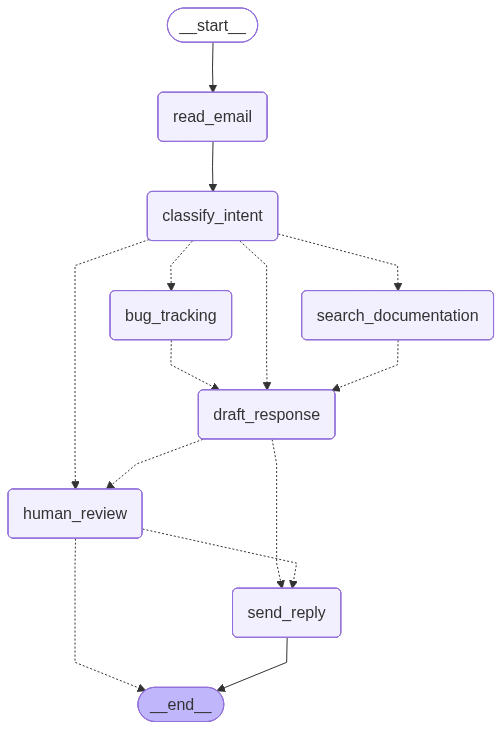

In [9]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import RetryPolicy

# Create the graph
workflow = StateGraph(EmailAgentState)

# Add nodes with appropriate error handling
workflow.add_node("read_email", read_email)
workflow.add_node("classify_intent", classify_intent)

# Add retry policy for nodes that might have transient failures
workflow.add_node(
    "search_documentation",
    search_documentation,
    retry_policy=RetryPolicy(max_attempts=3)
)
workflow.add_node("bug_tracking", bug_tracking)
workflow.add_node("draft_response", draft_response)
workflow.add_node("human_review", human_review)
workflow.add_node("send_reply", send_reply)

# Add only the essential edges
workflow.add_edge(START, "read_email")
workflow.add_edge("read_email", "classify_intent")
workflow.add_edge("send_reply", END)

# Compile with checkpointer for persistence, in case run graph with Local_Server --> Please compile without checkpointer
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

app

In [13]:
# Test with an urgent billing issue
initial_state = {
    "email_content": "There is a bug while exporting json",
    "sender_email": "customer@example.com",
    "messages": []
}

# Run with a thread_id for persistence
config = {"configurable": {"thread_id": "customer_1234"}}
result = app.invoke(initial_state, config)
# The graph will pause at human_review
if result.get('__interrupt__'):
    print(f"human review interrupt:{result['__interrupt__']}")

# When ready, provide human input to resume
from langgraph.types import Command

human_response = Command(
    resume={
        "approved": True,
        "edited_response": "We sincerely apologize for the double charge. I've initiated an immediate refund..."
    }
)

# Resume execution
final_result = app.invoke(human_response, config)
print(f"Email sent successfully!")

Sending reply: Subject: Assistance with JSON Export Issue

Dear [Customer Name],

Thank you for reaching out and br...
Email sent successfully!
